# Gradient Boosting Classifier - Bank Marketing Prediction

## Project Overview

This project implements a **Gradient Boosting Classifier** to predict whether a bank client will subscribe to a term deposit.

The project demonstrates an end-to-end classification workflow including data exploration, preprocessing of numerical and categorical features, class-distribution analysis, model training, evaluation, ROC-AUC analysis, feature importance, and investigation of the `duration` feature as a potential source of unrealistic predictive information.

The target variable is `y`, where `yes` indicates that the client subscribed to a term deposit and `no` indicates that they did not.


## 1. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTENC


## 2. Load Dataset


In [2]:
df = pd.read_csv("bank_marketing.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 3. Explore Dataset


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all").T)


Columns:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Data types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


## 4. Missing Values and Duplicates


In [4]:
print("Missing values:")
display(df.isnull().sum().to_frame("Missing Count"))

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:


,Missing Count
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0



Duplicate rows: 0


## 5. Target Distribution


y
no     39922
yes     5289
Name: count, dtype: int64

Target percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


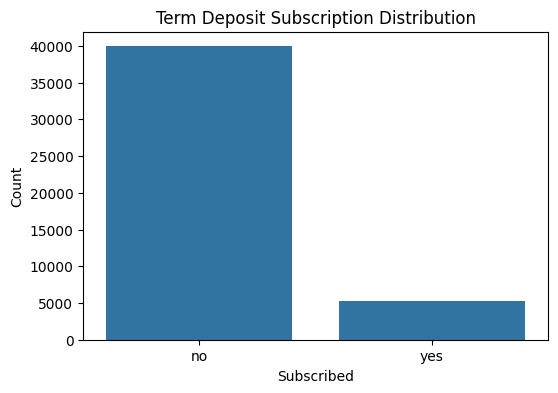

In [5]:
print(df["y"].value_counts())
print("\nTarget percentages:")
print((df["y"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscribed")
plt.ylabel("Count")
plt.show()


## 6. Exploratory Data Analysis


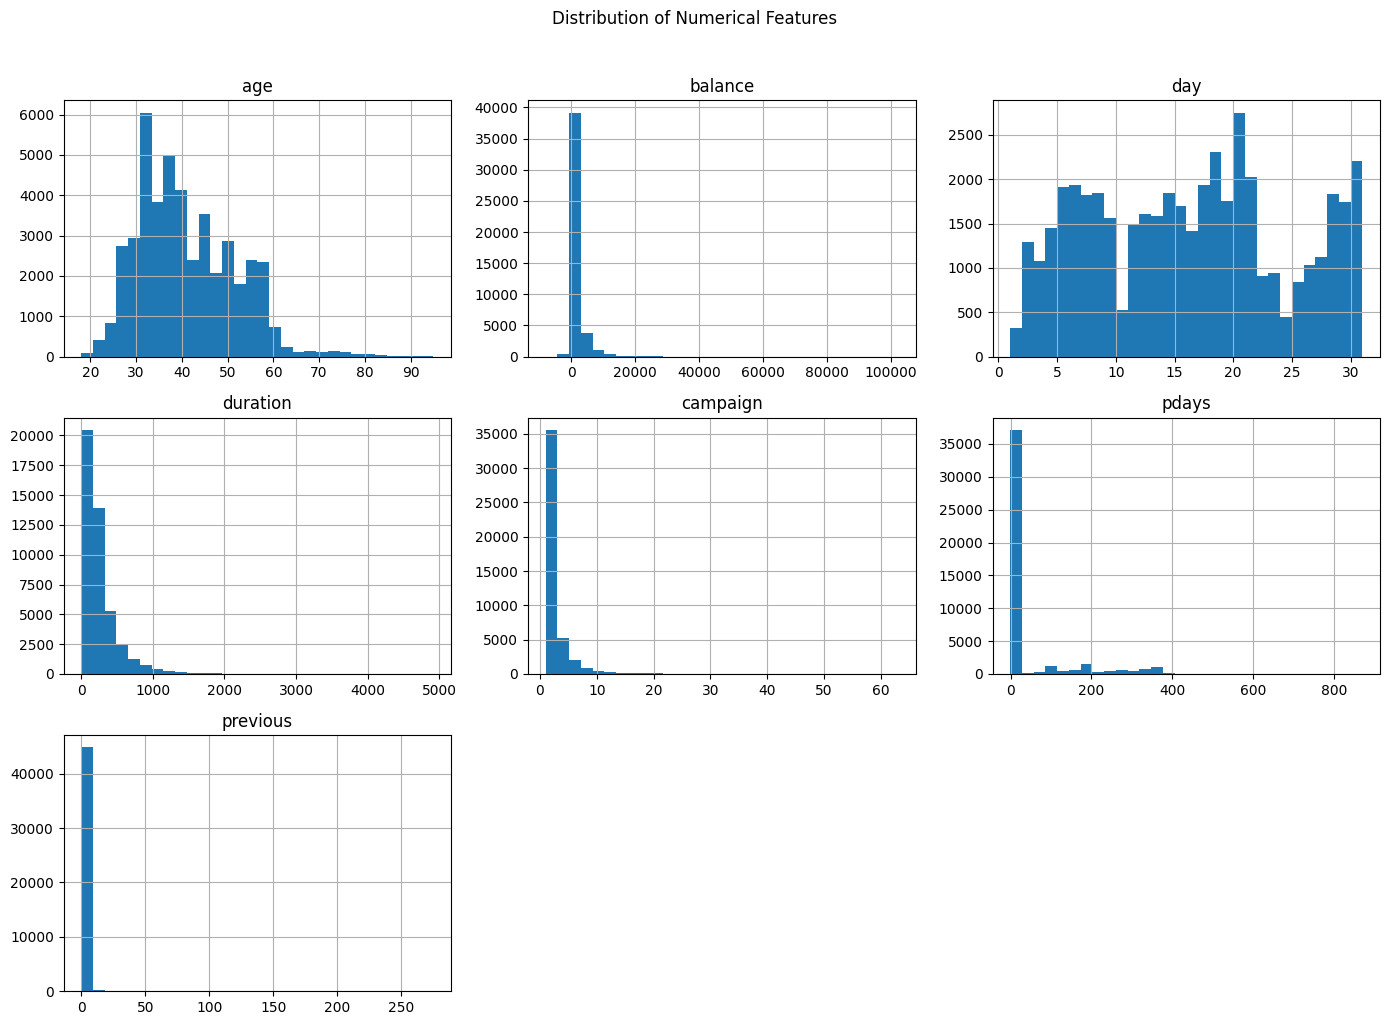

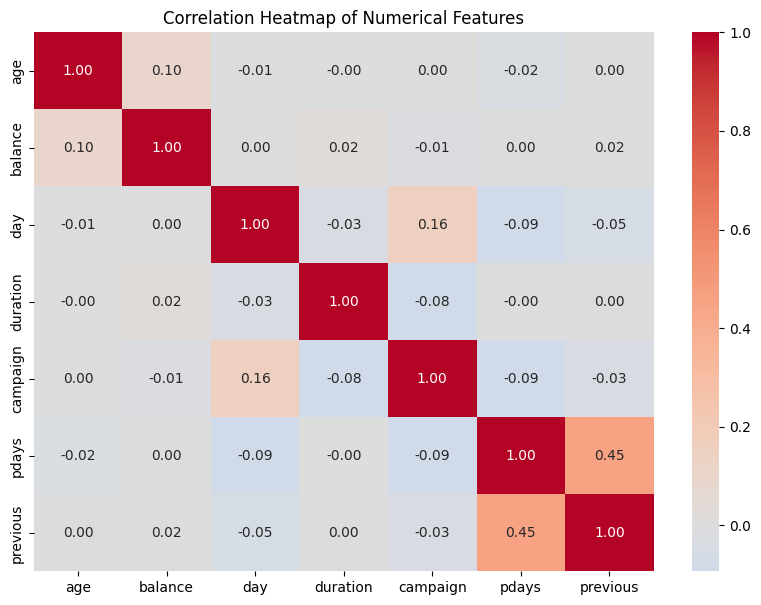

In [6]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribution of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[numerical_columns].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


## 7. Prepare Features and Target


In [7]:
X = df.drop(columns="y")
y = df["y"].map({"no": 0, "yes": 1})

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nEncoded target distribution:")
print(y.value_counts())


Feature matrix shape: (45211, 16)
Target shape: (45211,)

Encoded target distribution:
y
0    39922
1     5289
Name: count, dtype: int64


## 8. Identify Numerical and Categorical Features


In [8]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


## 9. Train-Test Split


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (36168, 16)
Test set shape: (9043, 16)


## 10. Preprocessing Pipeline


In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 11. Train Gradient Boosting Classifier


In [11]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)
print("Gradient Boosting Classifier trained successfully.")


Gradient Boosting Classifier trained successfully.


## 12. Make Predictions


In [12]:
y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:, 1]

print("Predictions generated:", len(y_pred))


Predictions generated: 9043


## 13. Model Evaluation


In [13]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))


Accuracy: 0.9055
ROC-AUC Score: 0.9240

Classification Report:
              precision    recall  f1-score   support

          No       0.93      0.97      0.95      7985
         Yes       0.65      0.41      0.50      1058

    accuracy                           0.91      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.91      0.90      9043



## 14. Confusion Matrix


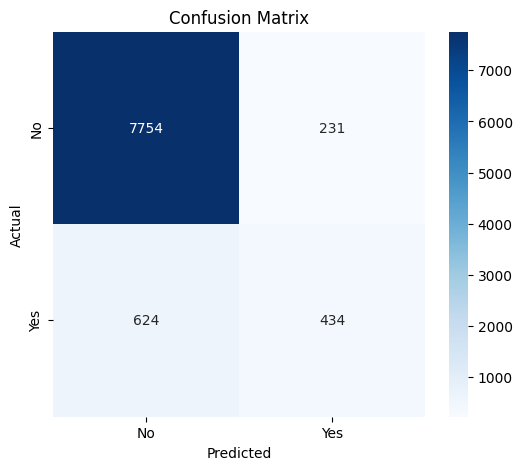

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 15. ROC Curve


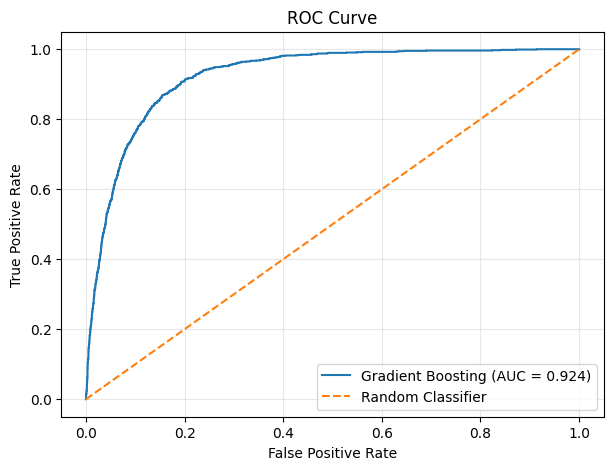

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 16. Feature Importance


,Feature,Importance
3,num__duration,0.469686
49,cat__poutcome_success,0.182730
34,cat__contact_unknown,0.039012
5,num__pdays,0.037297
42,cat__month_mar,0.032708
0,num__age,0.031424
28,cat__housing_no,0.031405
35,cat__month_apr,0.024795
41,cat__month_jun,0.024354
45,cat__month_oct,0.023785


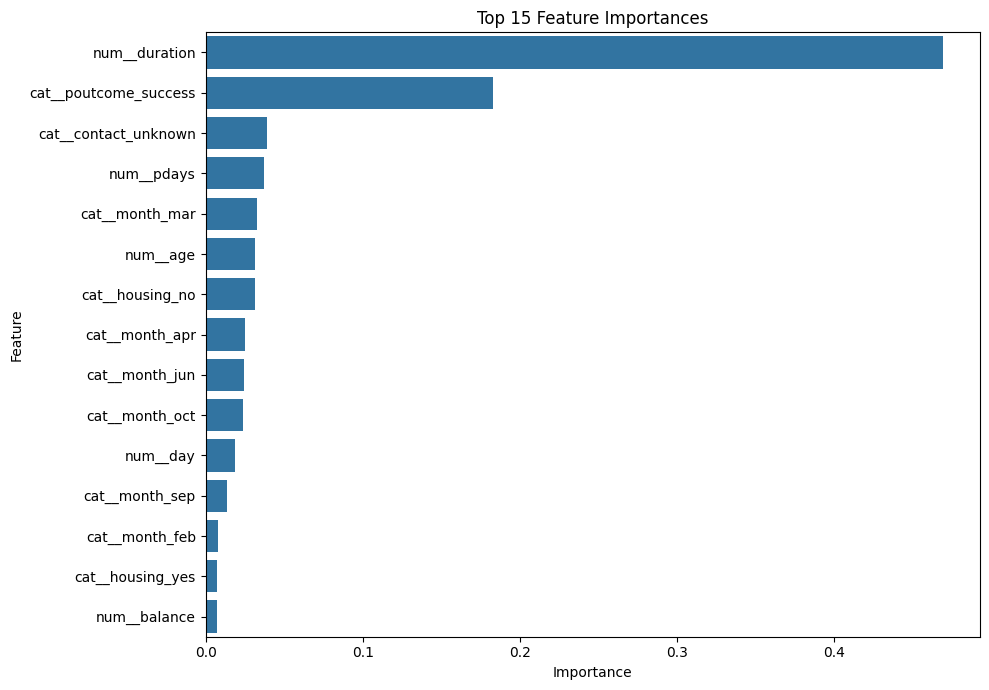

In [16]:
feature_names = gb_model.named_steps["preprocessor"].get_feature_names_out()
importances = gb_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feature_importance_df.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance_df.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


## 17. Duration Feature Analysis

The `duration` variable represents the duration of the last contact with a client. In the Bank Marketing dataset, this value is only known **after a call has occurred**.

If the objective is to predict whether a client will subscribe **before making the call**, using `duration` would provide information that is unavailable at prediction time.

To evaluate a more realistic pre-contact prediction scenario, a second Gradient Boosting model is trained after removing `duration`.


### 17.1 Prepare Duration-Free Features


In [17]:
X_no_duration = df.drop(columns=["y", "duration"])
y_no_duration = df["y"].map({"no": 0, "yes": 1})

num_no_duration = X_no_duration.select_dtypes(include=np.number).columns.tolist()
cat_no_duration = X_no_duration.select_dtypes(exclude=np.number).columns.tolist()

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_no_duration,
    y_no_duration,
    test_size=0.20,
    random_state=42,
    stratify=y_no_duration
)

print("Features with duration:", X.shape[1])
print("Features without duration:", X_no_duration.shape[1])


Features with duration: 16
Features without duration: 15


### 17.2 Train Duration-Free Model


In [18]:
preprocessor_nd = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_no_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_no_duration)
    ]
)

gb_model_nd = Pipeline(
    steps=[
        ("preprocessor", preprocessor_nd),
        ("classifier", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_model_nd.fit(X_train_nd, y_train_nd)

y_pred_nd = gb_model_nd.predict(X_test_nd)
y_prob_nd = gb_model_nd.predict_proba(X_test_nd)[:, 1]

accuracy_nd = accuracy_score(y_test_nd, y_pred_nd)
roc_auc_nd = roc_auc_score(y_test_nd, y_prob_nd)

print(f"Duration-Free Accuracy: {accuracy_nd:.4f}")
print(f"Duration-Free ROC-AUC: {roc_auc_nd:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_nd, y_pred_nd, target_names=["No", "Yes"]))


Duration-Free Accuracy: 0.8943
Duration-Free ROC-AUC: 0.8021

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.99      0.94      7985
         Yes       0.66      0.20      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



## 18. Model Comparison


In [19]:
comparison_df = pd.DataFrame({
    "Model": ["Full-Feature Model", "Duration-Free Model"],
    "Accuracy": [accuracy, accuracy_nd],
    "ROC-AUC": [roc_auc, roc_auc_nd]
})

display(comparison_df)


,Model,Accuracy,ROC-AUC
0,Full-Feature Model,0.905452,0.924038
1,Duration-Free Model,0.894283,0.802115


## 19. Class Imbalance Analysis

The target variable is highly imbalanced, with substantially fewer clients subscribing to a term deposit than not subscribing.

The duration-free model is the more realistic pre-contact model, but its recall for the positive (`Yes`) class is low. To investigate whether better minority-class representation can improve detection of subscribers, **SMOTENC** is applied to the duration-free training data.

SMOTENC is appropriate because the dataset contains both numerical and categorical variables. Oversampling is applied **only to the training set** so that the test set remains untouched and continues to represent the original data distribution.


### 19.1 Prepare Data for SMOTENC


In [20]:
X_smote = X_no_duration.copy()

# SMOTENC expects categorical columns to be represented as categorical values.
for col in cat_no_duration:
    X_smote[col] = X_smote[col].astype("category")

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X_smote,
    y_no_duration,
    test_size=0.20,
    random_state=42,
    stratify=y_no_duration
)

print("Training target distribution before oversampling:")
print(y_train_sm.value_counts())


Training target distribution before oversampling:
y
0    31937
1     4231
Name: count, dtype: int64


### 19.2 Apply SMOTENC to Training Data


In [21]:
categorical_indices = [
    X_train_sm.columns.get_loc(col)
    for col in cat_no_duration
]

smotenc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_resampled, y_train_resampled = smotenc.fit_resample(
    X_train_sm,
    y_train_sm
)

print("Training target distribution after SMOTENC:")
print(y_train_resampled.value_counts())

print(
    f"\nTraining rows before SMOTENC: {len(X_train_sm):,}"
    f"\nTraining rows after SMOTENC:  {len(X_train_resampled):,}"
)


Training target distribution after SMOTENC:
y
0    31937
1    31937
Name: count, dtype: int64

Training rows before SMOTENC: 36,168
Training rows after SMOTENC:  63,874


### 19.3 Preprocess Resampled Data


In [22]:
# Convert the resampled data back to a DataFrame if necessary
X_train_resampled = pd.DataFrame(
    X_train_resampled,
    columns=X_train_sm.columns
)

# Ensure categorical columns remain categorical/string-like for OneHotEncoder
for col in cat_no_duration:
    X_train_resampled[col] = X_train_resampled[col].astype(str)
    X_test_sm[col] = X_test_sm[col].astype(str)

preprocessor_smote = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_no_duration),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_no_duration)
    ]
)

X_train_resampled_processed = preprocessor_smote.fit_transform(X_train_resampled)
X_test_sm_processed = preprocessor_smote.transform(X_test_sm)

print("Processed resampled training shape:", X_train_resampled_processed.shape)
print("Processed test shape:", X_test_sm_processed.shape)


Processed resampled training shape: (63874, 50)
Processed test shape: (9043, 50)


### 19.4 Train Gradient Boosting with Oversampled Data


In [23]:
gb_model_smote = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model_smote.fit(X_train_resampled_processed, y_train_resampled)

y_pred_smote = gb_model_smote.predict(X_test_sm_processed)
y_prob_smote = gb_model_smote.predict_proba(X_test_sm_processed)[:, 1]

accuracy_smote = accuracy_score(y_test_sm, y_pred_smote)
roc_auc_smote = roc_auc_score(y_test_sm, y_prob_smote)

print(f"SMOTENC Model Accuracy: {accuracy_smote:.4f}")
print(f"SMOTENC Model ROC-AUC: {roc_auc_smote:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_sm, y_pred_smote, target_names=["No", "Yes"]))


SMOTENC Model Accuracy: 0.7585
SMOTENC Model ROC-AUC: 0.7704

Classification Report:
              precision    recall  f1-score   support

          No       0.94      0.78      0.85      7985
         Yes       0.27      0.62      0.38      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043



### 19.5 SMOTENC Confusion Matrix


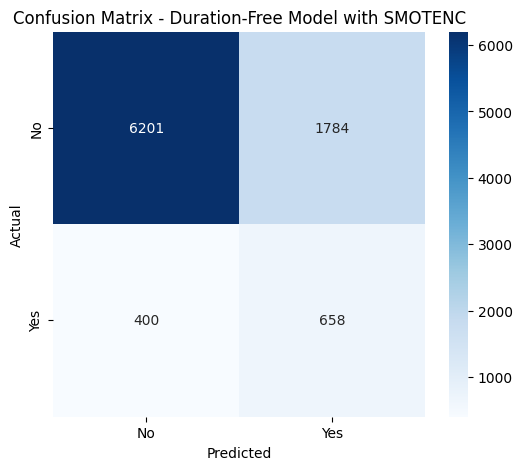

In [24]:
cm_smote = confusion_matrix(y_test_sm, y_pred_smote)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)
plt.title("Confusion Matrix - Duration-Free Model with SMOTENC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 20. Final Model Comparison


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_final_df = pd.DataFrame({
    "Model": [
        "Full-Feature Model",
        "Duration-Free Model",
        "Duration-Free + SMOTENC"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nd,
        accuracy_smote
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_nd,
        roc_auc_smote
    ],
    "Yes Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test_nd, y_pred_nd),
        precision_score(y_test_sm, y_pred_smote)
    ],
    "Yes Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test_nd, y_pred_nd),
        recall_score(y_test_sm, y_pred_smote)
    ],
    "Yes F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test_nd, y_pred_nd),
        f1_score(y_test_sm, y_pred_smote)
    ]
})

display(comparison_final_df.round(4))


,Model,Accuracy,ROC-AUC,Yes Precision,Yes Recall,Yes F1
0,Full-Feature Model,0.9055,0.9240,0.6526,0.4102,0.5038
1,Duration-Free Model,0.8943,0.8021,0.6594,0.1994,0.3062
2,Duration-Free + SMOTENC,0.7585,0.7704,0.2695,0.6219,0.3760


## 21. Key Findings

- The full-feature Gradient Boosting model achieved **90.55% accuracy** and **0.9240 ROC-AUC**.
- `duration` was the dominant feature, accounting for approximately **46.97% of feature importance**.
- Since `duration` is unavailable before a marketing call occurs, removing it provides a more realistic pre-call prediction scenario.
- The duration-free model achieved **89.43% accuracy** and **0.8021 ROC-AUC**, but `Yes` recall decreased to **19.94%**.
- The strong target-class imbalance makes accuracy alone insufficient for evaluating the model's ability to identify subscribers.
- Applying SMOTENC to the duration-free training data increased `Yes` recall from **19.94% to 62.19%**.
- Positive-class F1 improved from **30.62% to 37.60%** after oversampling.
- The improvement in recall came with lower `Yes` precision (**65.94% → 26.95%**) and lower overall accuracy (**89.43% → 75.85%**).
- The experiments demonstrate the **precision-recall trade-off** involved when oversampling an imbalanced classification dataset.

## 22. Conclusion

This project demonstrated **Gradient Boosting Classification** for predicting term-deposit subscriptions while highlighting two important practical issues: feature availability and class imbalance.

The full-feature model achieved **90.55% accuracy** and **0.9240 ROC-AUC**, but depended heavily on `duration`, a feature that would not be available before contacting a client. Removing `duration` produced a more realistic pre-call model but reduced positive-class recall to **19.94%**.

Applying SMOTENC oversampling substantially increased subscriber recall to **62.19%** and improved the positive-class F1 score, although precision and overall accuracy decreased.

Overall, the results show that model performance must be evaluated according to the prediction objective. The duration-free model produces more precise positive predictions, while the SMOTENC model identifies a much larger proportion of potential subscribers. The project also demonstrates why accuracy alone is insufficient for evaluating imbalanced classification problems.